In [3]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv('Car data.csv')

In [11]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [12]:
df.columns


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

In [13]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [14]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

In [16]:
df.shape

(301, 9)

In [18]:
duplicated_rows= df[df.duplicated()]
duplicated_rows.shape

(2, 9)

In [19]:
df = df.drop_duplicates()
df.shape

(299, 9)

In [20]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

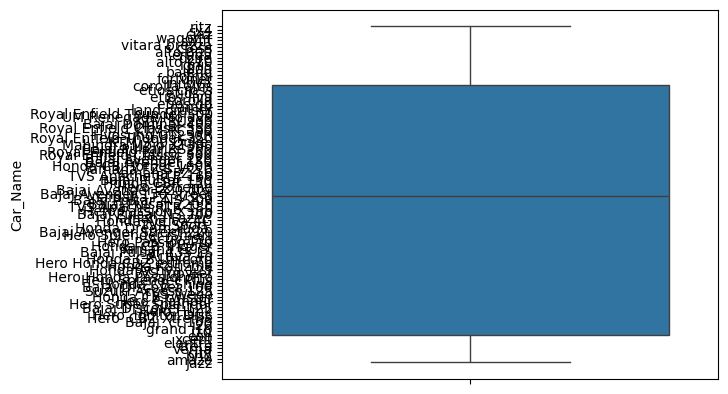

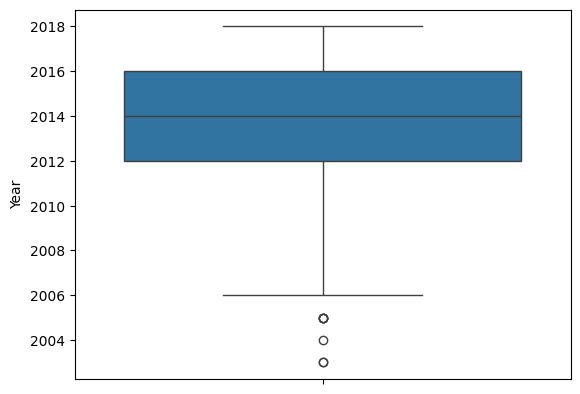

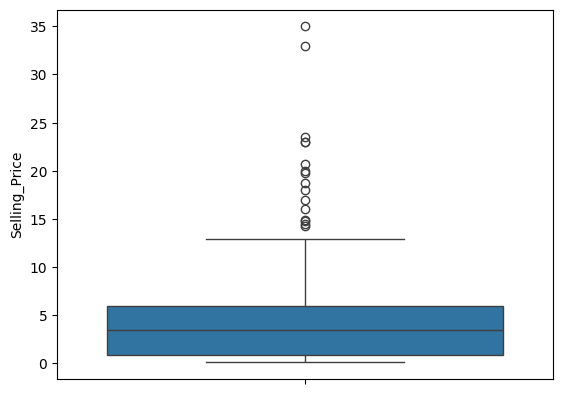

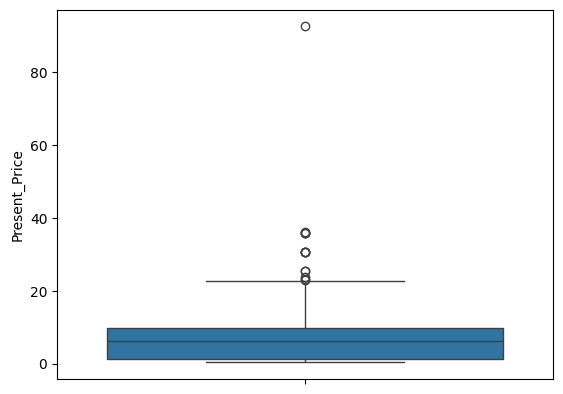

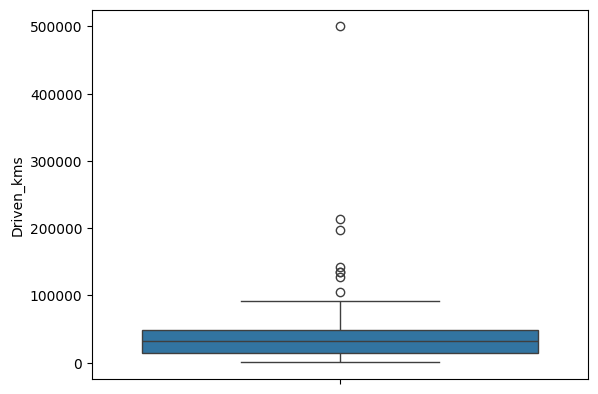

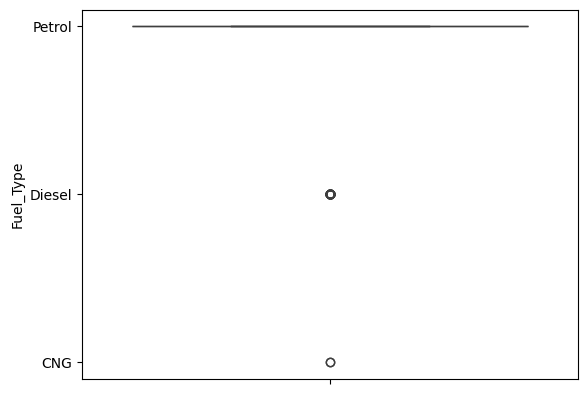

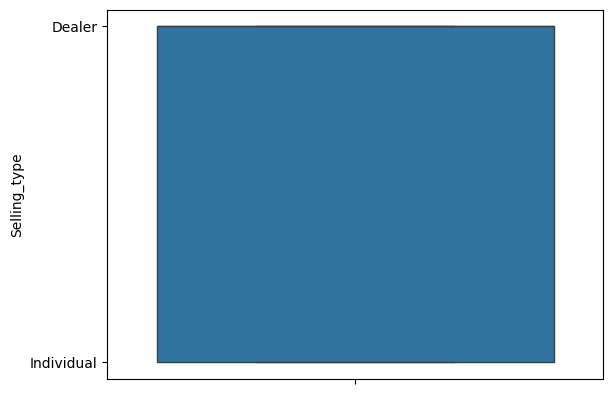

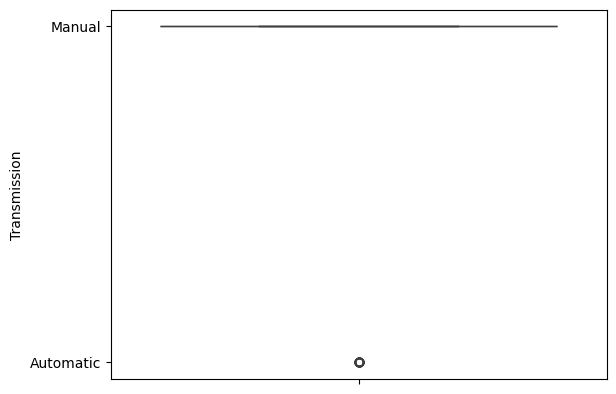

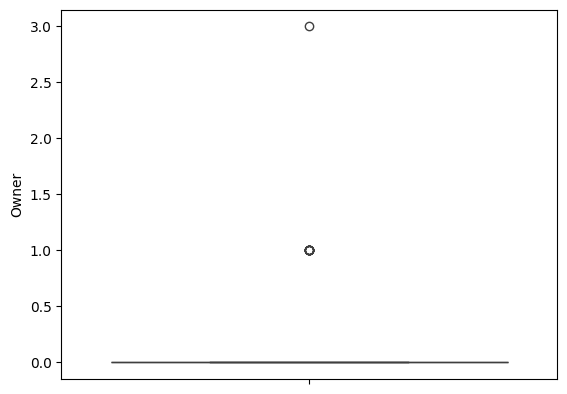

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt 

features=['Car_Name','Year','Selling_Price','Present_Price','Driven_kms','Fuel_Type','Selling_type','Transmission','Owner']

for i in features:
    sns.boxplot(df[i])
    plt.show()
    


In [27]:
numeric_features = df.select_dtypes(include=[np.number]).columns

for i in numeric_features:
    a = df[i].median()
    print(i, ' median value : ', a)
    df[i] = df[i].fillna(a)

Year  median value :  2014.0
Selling_Price  median value :  3.51
Present_Price  median value :  6.1
Driven_kms  median value :  32000.0
Owner  median value :  0.0


In [62]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_features

['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']

In [30]:
cat_features=[feature for feature in df.columns if df[feature].dtype == 'O']
cat_features

[]

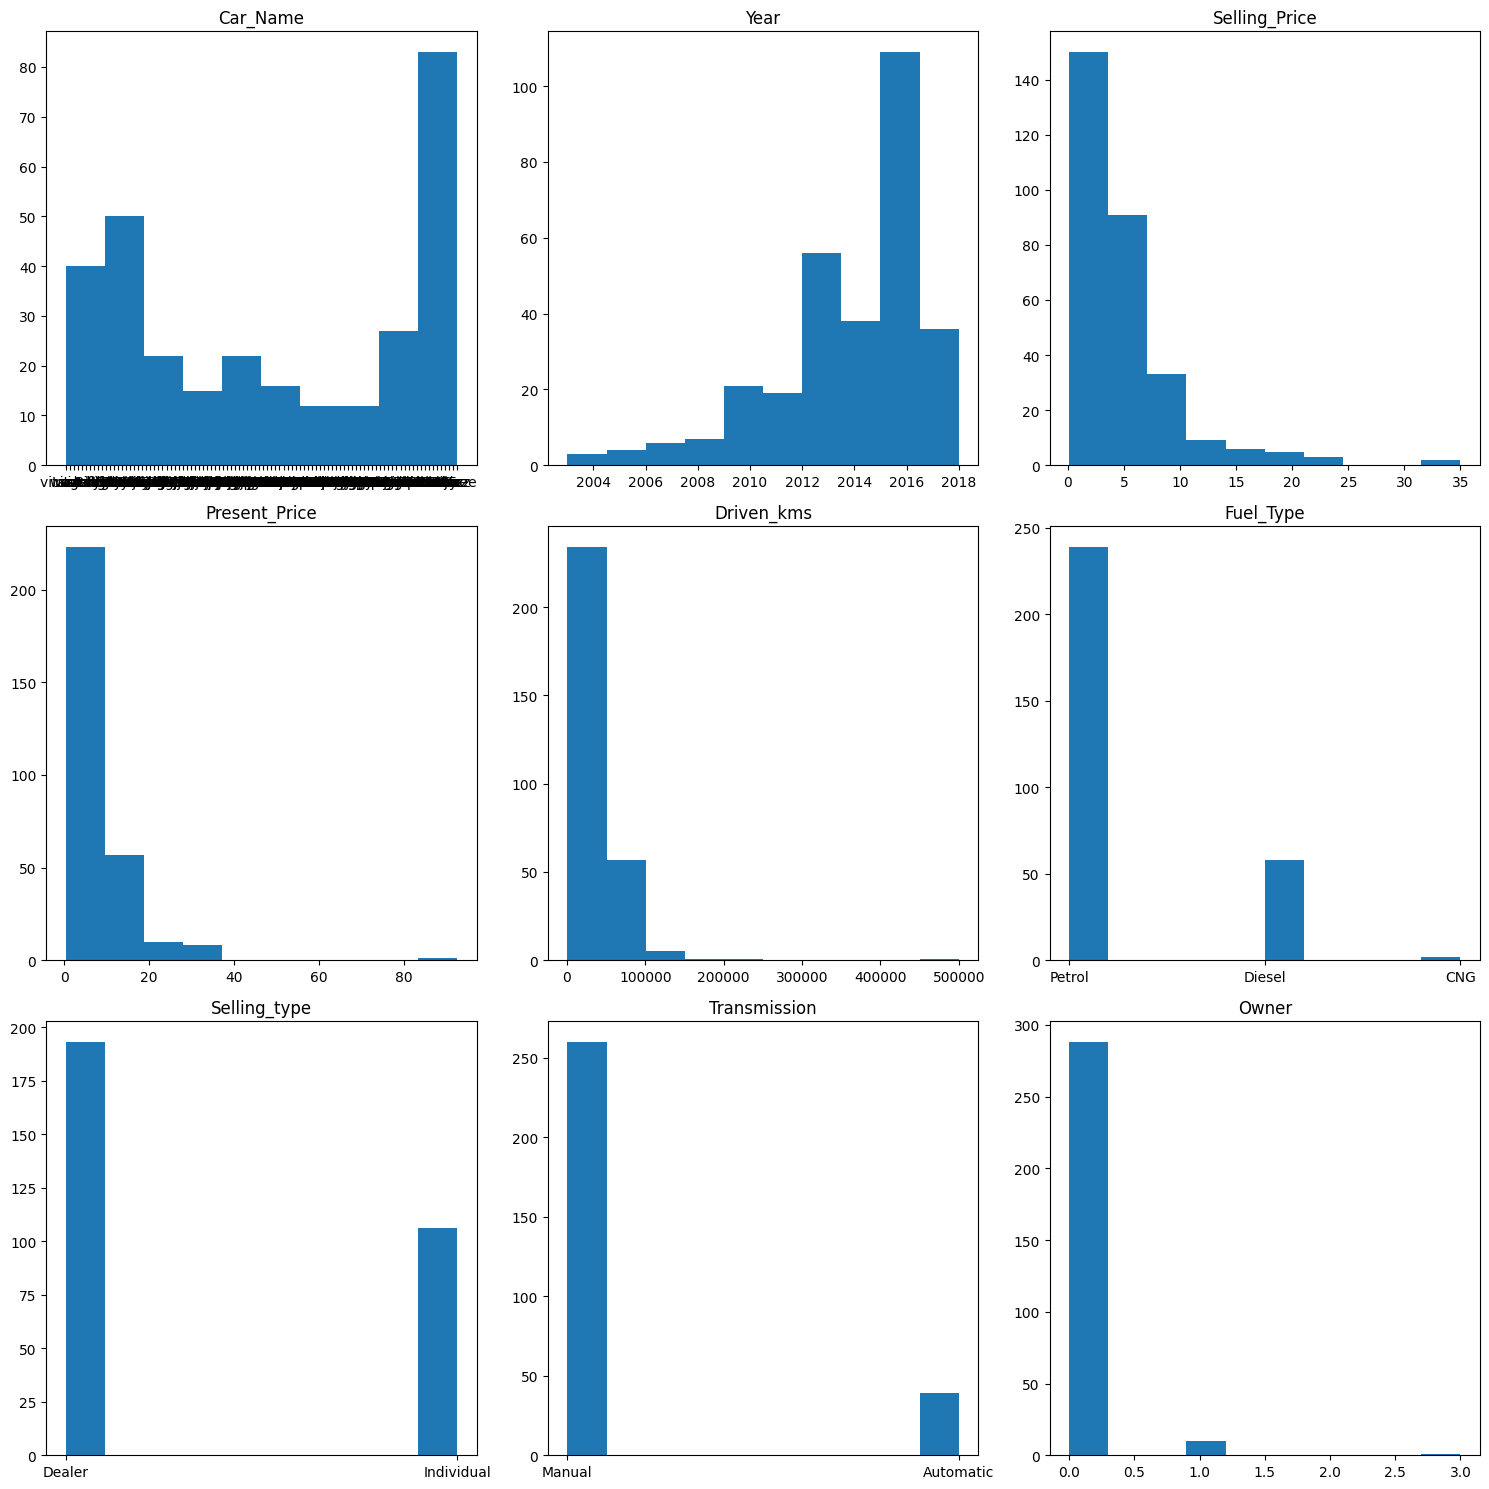

In [33]:
fig,axs= plt.subplots(3,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(df.columns):
    axs[i].hist(df[feature])
    axs[i].set_title(feature)
plt.tight_layout()
plt.show()



In [41]:
b= df.groupby("Driven_kms")["Present_Price"].mean()
b

Driven_kms
500        0.745
1000       0.550
1200       1.600
1300       0.730
1400       1.820
           ...  
135154    12.350
142000    23.730
197176    13.460
213000     1.050
500000     0.520
Name: Present_Price, Length: 206, dtype: float64

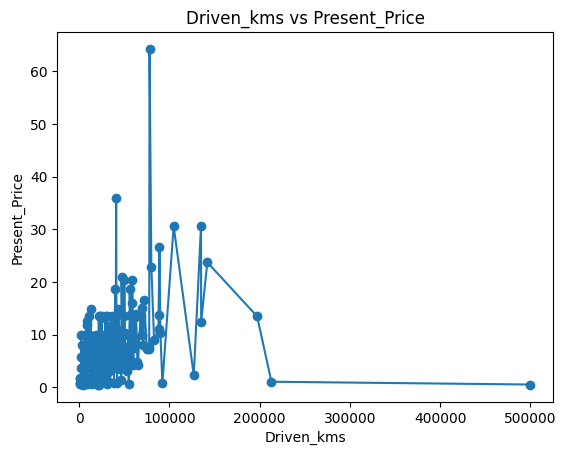

In [36]:
plt.plot(b.index, b.values , marker="o")
plt.title("Driven_kms vs Present_Price")
plt.xlabel("Driven_kms")
plt.ylabel("Present_Price")
plt.show()

In [42]:
# effect of fuel type
c = df.groupby("Fuel_Type")["Present_Price"].mean()
c

Fuel_Type
CNG        6.415000
Diesel    15.646034
Petrol     5.583556
Name: Present_Price, dtype: float64

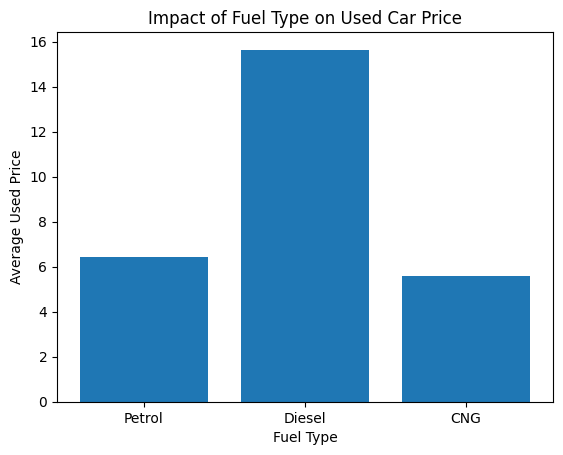

In [43]:
c = df.groupby("Fuel_Type")["Present_Price"].mean()

plt.bar(c.index, c.values)
plt.xticks([0,1,2], ["Petrol", "Diesel", "CNG"])
plt.xlabel("Fuel Type")
plt.ylabel("Average Used Price")
plt.title("Impact of Fuel Type on Used Car Price")

plt.show()

In [47]:
d = df.groupby("Driven_kms")["Present_Price"].mean()
d

Driven_kms
500        0.745
1000       0.550
1200       1.600
1300       0.730
1400       1.820
           ...  
135154    12.350
142000    23.730
197176    13.460
213000     1.050
500000     0.520
Name: Present_Price, Length: 206, dtype: float64

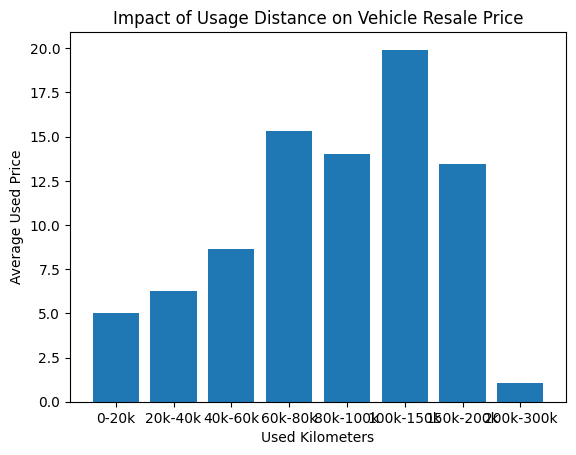

In [52]:


df["Driven_kms_group"] = pd.cut(
    df["Driven_kms"],
    bins=[0,20000,40000,60000,80000,100000,150000,200000,300000,400000],
    labels=["0-20k","20k-40k","40k-60k","60k-80k","80k-100k","100k-150k","150k-200k","200k-300k","300k-400k+"]
)

d = df.groupby("Driven_kms_group")["Present_Price"].mean()

plt.bar(d.index, d.values)

plt.xlabel("Used Kilometers")
plt.ylabel("Average Used Price")
plt.title("Impact of Usage Distance on Vehicle Resale Price")

plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97],
 [Text(0, 0, 'city'),
  Text(1, 0, 'corolla altis'),
  Text(2, 0, 'verna'),
  Text(3, 0, 'fortuner'),
  Text(4, 0, 'brio'),
  Text(5, 0, 'ciaz'),
  Text(6, 0, 'innova'),
  Text(7, 0, 'i20'),
  Text(8, 0, 'grand i10'),
  Text(9, 0, 'Royal Enfield Classic 350'),
  Text(10, 0, 'amaze'),
  Text(11, 0, 'jazz'),
  Text(12, 0, 'sx4'),
  Text(13, 0, 'eon'),
  Text(14, 0, 'swift'),
  Text(15, 0, 'ertiga'),
  Text(16, 0, 'alto 

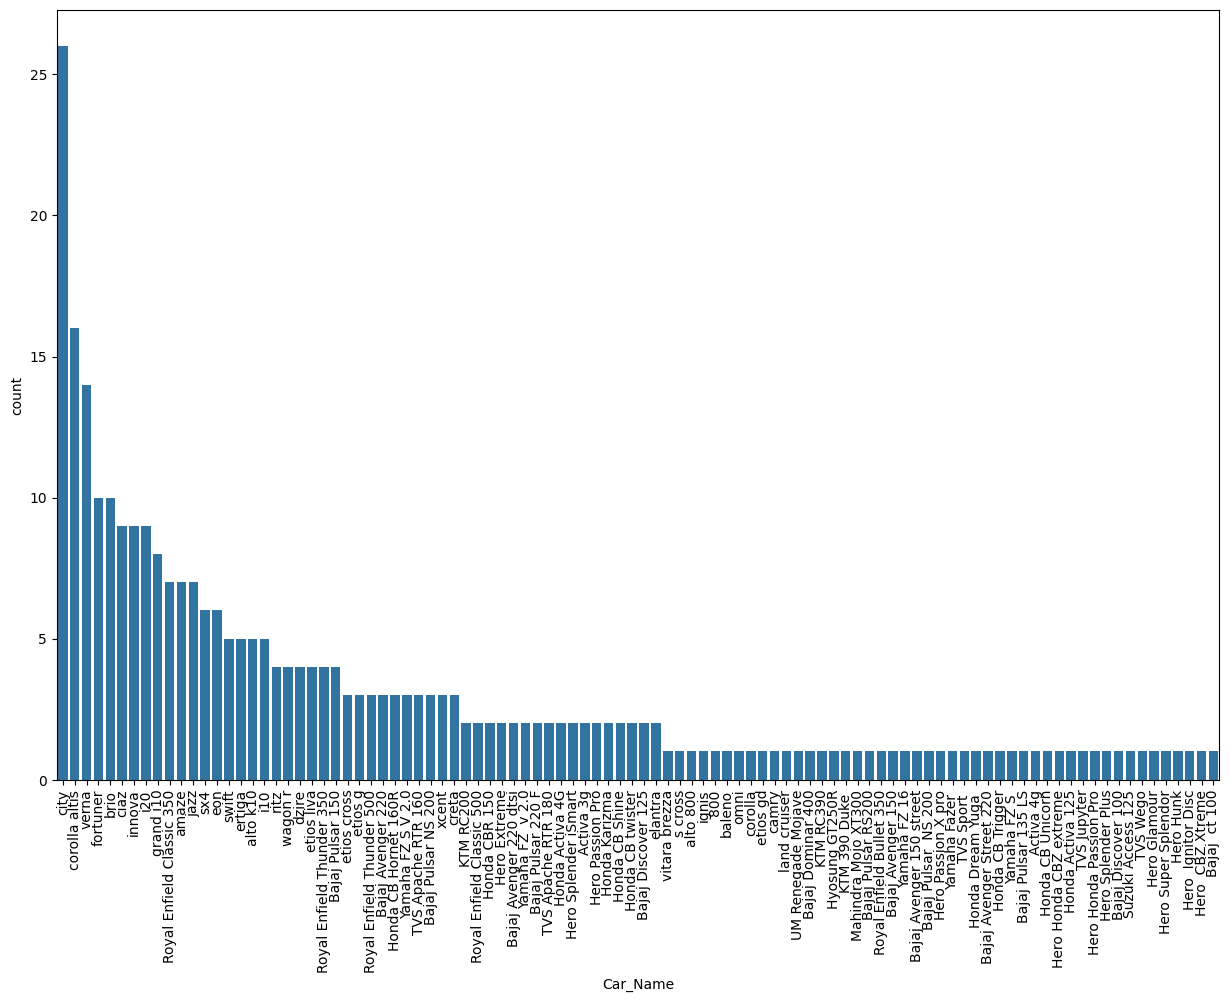

In [54]:
fig= plt.figure(figsize=(15,10))
sns.countplot(x=df.Car_Name,order=df["Car_Name"].value_counts().index)
plt.xticks(rotation=90)

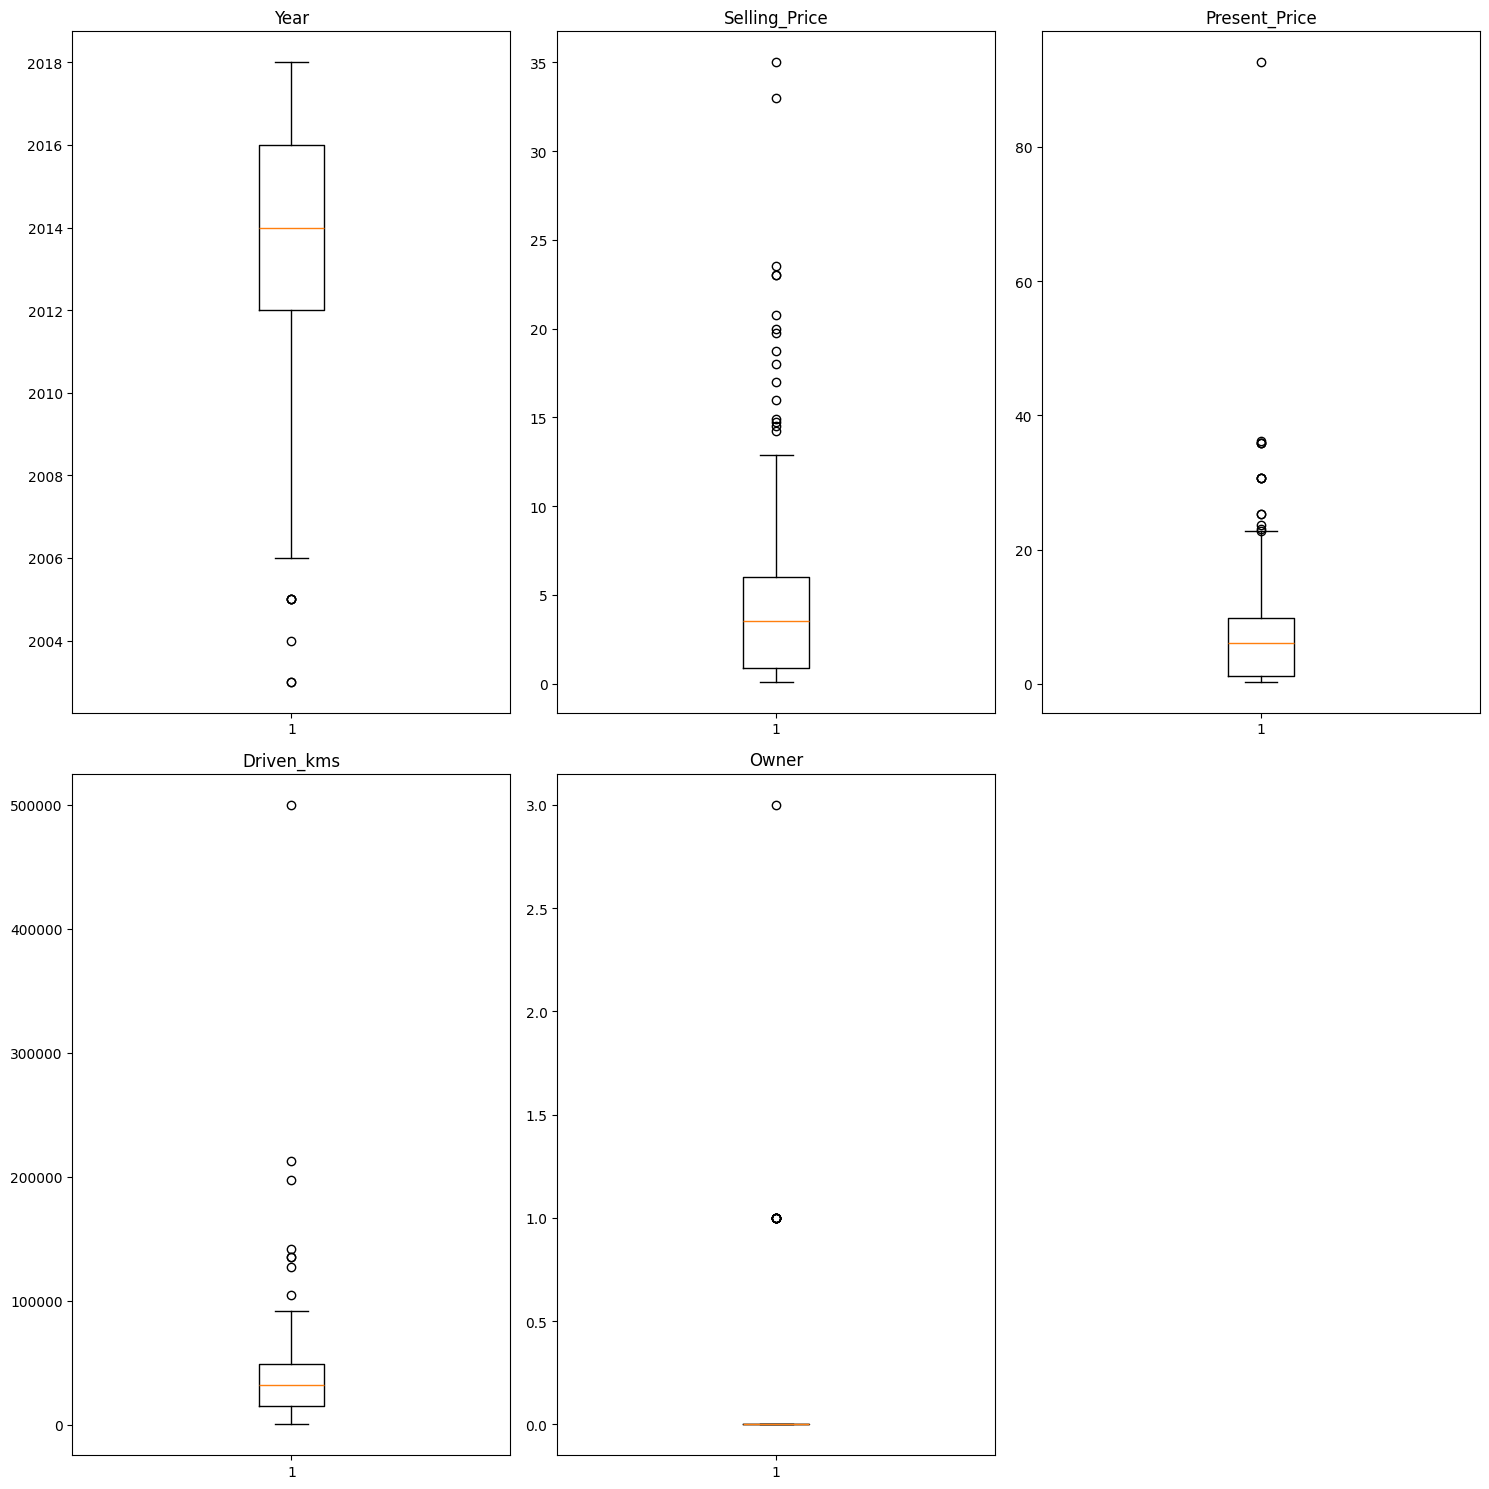

In [67]:
fig,axs= plt.subplots(2,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(num_features):
    
    axs[i].boxplot(df[feature])
    axs[i].set_title(feature)


fig.delaxes(axs[-1])

plt.tight_layout()

plt.show()

In [63]:
print(num_features)
print(df[num_features].dtypes)
print(df[num_features].head())

['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Owner              int64
dtype: object
   Year  Selling_Price  Present_Price  Driven_kms  Owner
0  2014           3.35           5.59       27000      0
1  2013           4.75           9.54       43000      0
2  2017           7.25           9.85        6900      0
3  2011           2.85           4.15        5200      0
4  2014           4.60           6.87       42450      0


In [70]:
features=['Year','Selling_Price','Present_Price','Driven_kms']

for i in features:
    lower = df[i].quantile(0.10)
    upper = df[i].quantile(0.90)
    df[i] = np.where(df[i] <lower, lower,df[i])
    df[i] = np.where(df[i] >upper, upper,df[i])
    print('Feature: ',i)
    print('Skewness value: ',df[i].skew())
    print('\n')
    

Feature:  Year
Skewness value:  -0.4096970037137206


Feature:  Selling_Price
Skewness value:  0.4260206430411395


Feature:  Present_Price
Skewness value:  0.3469709313603166


Feature:  Driven_kms
Skewness value:  0.22338528293418067




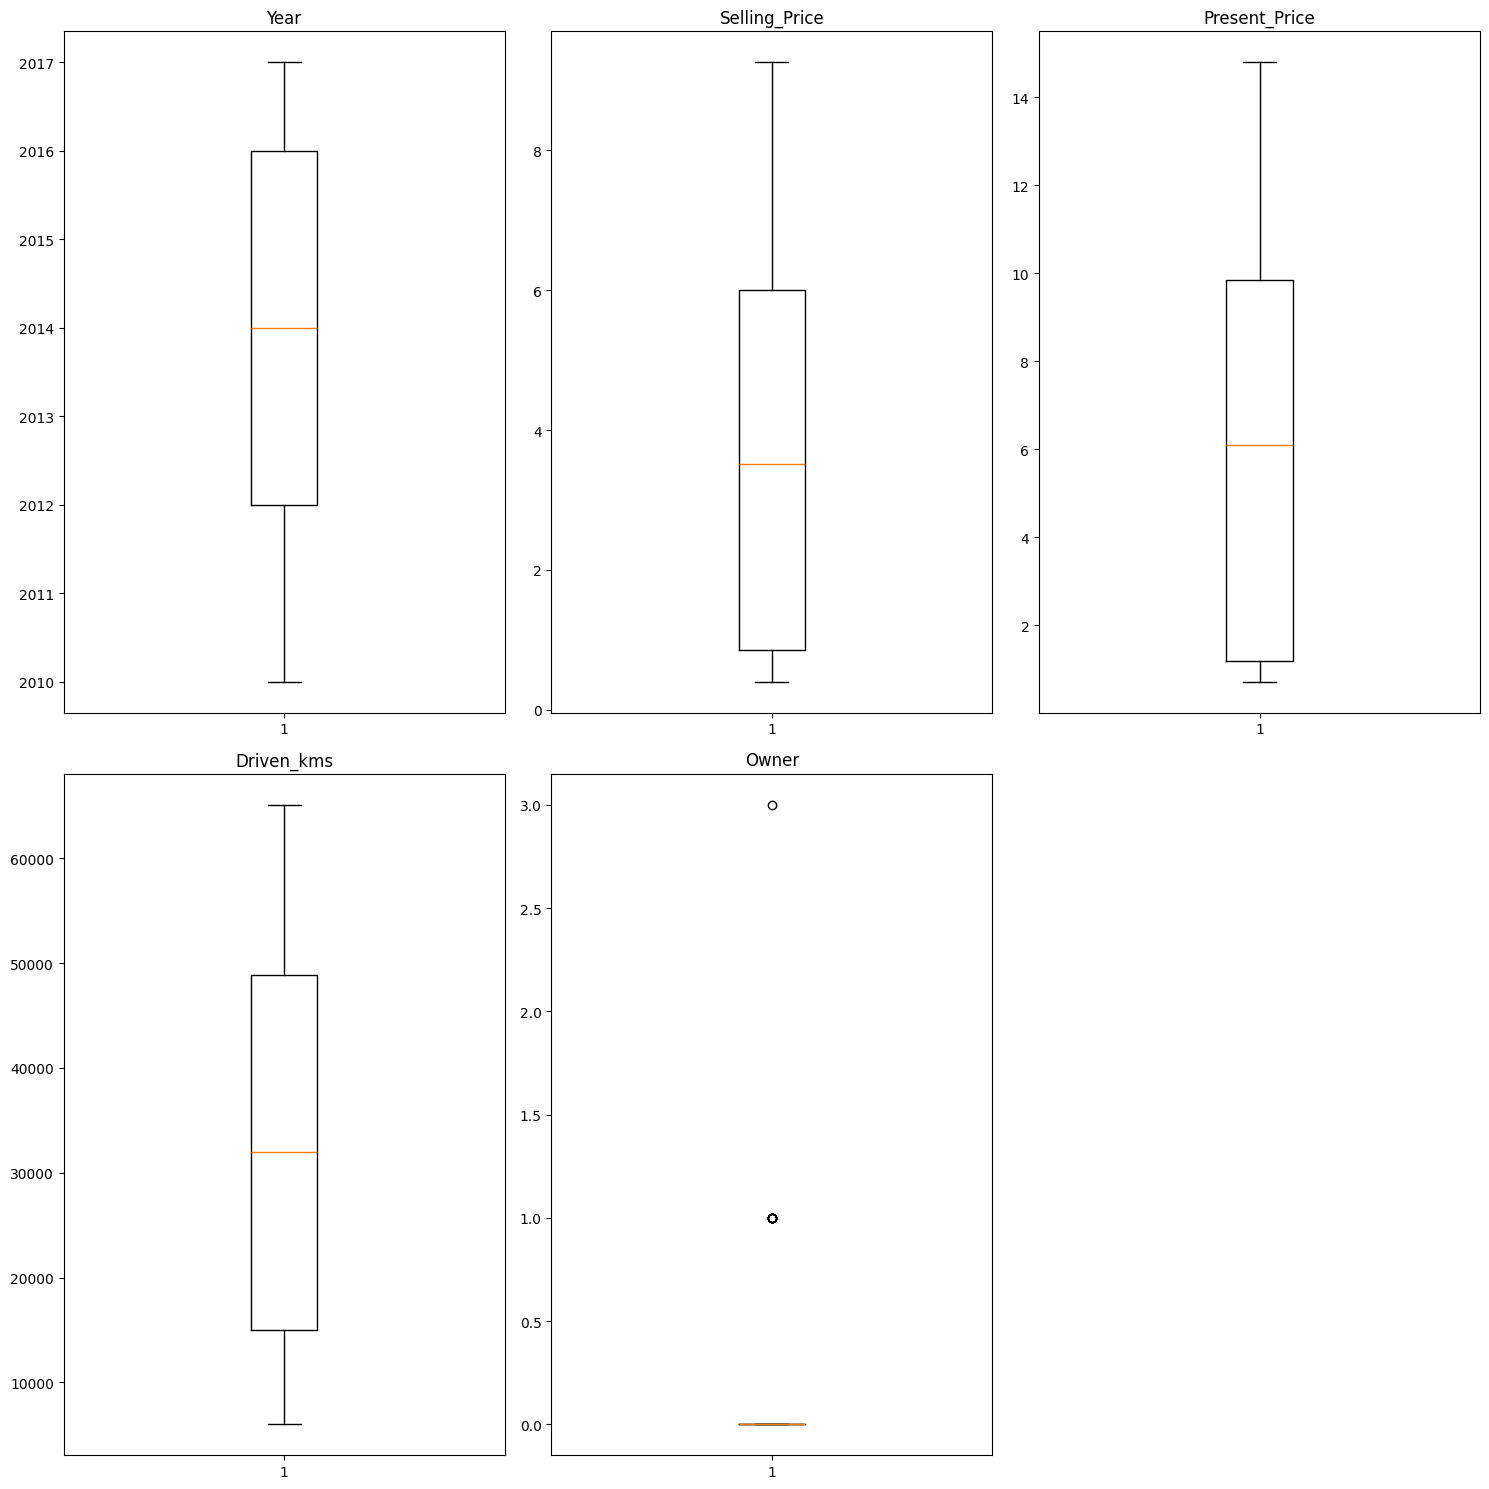

In [71]:
fig,axs= plt.subplots(2,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(num_features):
    
    axs[i].boxplot(df[feature])
    axs[i].set_title(feature)


fig.delaxes(axs[-1])

plt.tight_layout()

plt.show()

In [73]:
bi_num=['Car_Name','Year','Selling_Price','Present_Price','Driven_kms','Fuel_Type','Selling_type','Transmission','Owner']

In [84]:
X= df.drop('Selling_Price',axis=1)
y= df.Selling_Price


for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()


X.dtypes == object

C:\Users\VIVEK\AppData\Local\Temp\ipykernel_1828\4270476286.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X.select_dtypes("object"):


Car_Name            False
Year                False
Present_Price       False
Driven_kms          False
Fuel_Type           False
Selling_type        False
Transmission        False
Owner               False
Driven_kms_group    False
dtype: bool

In [89]:
from sklearn.model_selection import train_test_split
 

def dataset(X,y):
    train_full_X, val_X, train_full_y, val_y = train_test_split(X, y,test_size=0.2,random_state = 0)


    train_X, test_X, train_y, test_y = train_test_split(train_full_X, train_full_y, test_size=0.25,random_state = 0)
    return (train_X, val_X, train_y, val_y)

In [90]:
scores=[]

In [93]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

X= df.drop('Selling_Price',axis=1)
y= df.Selling_Price

X=pd.get_dummies(X)


#X= scale(X)
#X= PCAx(X)

X_train,X_val,y_train,y_val= dataset(X,y)

decision_model1= DecisionTreeRegressor(random_state=1)
decision_model1.fit(X_train, y_train)
preds= decision_model1.predict(X_val)

r2= r2_score(y_val,preds)
MSE= mean_squared_error(y_val,preds)


a= "Decision Tree Regreesion with all features"
print(a)
print("R2: ",round(r2,4))
print("MSE: ",round(MSE,4))

scores.append((a,round(r2,4),round(MSE,4)))


Decision Tree Regreesion with all features
R2:  0.9391
MSE:  0.5637


In [94]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
X= df.drop('Selling_Price',axis=1)
y= df.Selling_Price

X=pd.get_dummies(X)


# X= scale(X)
# X= PCAx(X)
X_train,X_val,y_train,y_val= dataset(X,y)

random_model1= RandomForestRegressor(random_state=1)
random_model1.fit(X_train, y_train)
preds= random_model1.predict(X_val)

r2= r2_score(y_val,preds)
MSE= mean_squared_error(y_val,preds)


a= "Random Forest Regression with all features"
print(a)
print("R2: ",round(r2,4))
print("MSE: ",round(MSE,4))

scores.append((a,round(r2,4),round(MSE,4)))


Random Forest Regression with all features
R2:  0.9578
MSE:  0.3904


In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X = pd.get_dummies(X)


X_train, X_val, y_train, y_val = dataset(X, y)

linear_model1 = LinearRegression()
linear_model1.fit(X_train, y_train)

preds = linear_model1.predict(X_val)


r2 = r2_score(y_val, preds)
MSE = mean_squared_error(y_val, preds)

a = "Linear Regression with all features"

print(a)
print("R2:", round(r2, 4))
print("MSE:", round(MSE, 4))


scores.append((a, round(r2, 4), round(MSE, 4)))

Linear Regression with all features
R2: 0.9076
MSE: 0.8552


In [96]:
scores

[('Decision Tree Regreesion with all features', 0.9391, 0.5637),
 ('Random Forest Regression with all features', 0.9578, 0.3904),
 ('Linear Regression with all features', 0.9076, 0.8552)]

In [97]:

import joblib
max_price = df['Selling_Price'].max()  # usually 1, but safe

# better: use original scale reference
scale_factor = df['Selling_Price'].max()

joblib.dump(scale_factor, "scale.pkl")

['scale.pkl']

In [98]:


joblib.dump(linear_model1, "model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']